# 06. double-gyre 순환과 시리즈 결합 (capstone)

마지막 실습에서는 **이중 gyre(double-gyre)** 풍성순환을 만들고, 이 모델이
생성한 속도장을 시리즈의 다른 프로젝트들과 연결한다.

이 시리즈의 큰 그림:

| 프로젝트 | 역할 |
|---|---|
| **shallow-water-lab** (이 프로젝트) | 격자 PDE 로 **속도장/모델을 직접 생성**(전진모델) |
| **particle-tracking-lab** | 주어진 속도장을 *따라다님*(라그랑지안 입자추적) |
| **advection-diffusion-lab** | 주어진 속도장 위에서 *트레이서 수송*(오일러리안) |
| **lorenz-da-lab** | 모델에 관측을 *동화*(자료동화) |

지금까지는 해석적 속도장(double-gyre 함수)을 *가정*해 위 실습들을 했다.
이제는 천수방정식이 **스스로 만든** double-gyre 속도장으로 같은 일을 한다.

학습 목표:

1. 이중 gyre 풍성순환을 정상상태까지 적분한다.
2. 모델 속도장을 저장한다(`outputs/fields/`).
3. 그 속도장에서 **입자추적**(RK4)을 수행한다 → `particle-tracking-lab` 결합.
4. 그 속도장 위에서 **트레이서 수송**(준라그랑지안)을 수행한다 → `advection-diffusion-lab` 결합.

## 1. 라이브러리

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def find_project_root(markers=("pyproject.toml", ".git")):
    # 노트북에는 __file__ 이 없으므로 cwd 에서 위로 올라가며 루트를 찾는다.
    start = Path.cwd().resolve()
    for path in (start, *start.parents):
        if any((path / m).exists() for m in markers):
            return path
    return start.parent if start.name == "notebooks" else start


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import map_coordinates

from shallow_water.grids.cgrid import CGrid
from shallow_water.dynamics.swe2d import ShallowWater2D
from shallow_water.dynamics import diagnostics as diag
from shallow_water.forcing import wind
from shallow_water.utils.io import get_output_dirs

OUT = get_output_dirs(PROJECT_ROOT); FIG = OUT["figures"]; FIELDS = OUT["fields"]

## 2. 이중 gyre 풍성순환

바람응력 $\tau_x(y)=-\tau_0\cos(2\pi y/L_y)$ 는 회전의 부호가 중앙에서 바뀌어
위·아래로 반대 방향의 두 gyre(아극·아열대)를 만든다. 측면점성(Munk)으로
정상상태까지 적분한다.

In [2]:
g, H, f0, beta = 9.81, 500.0, 1e-4, 2e-11
Lx = Ly = 2e6
n = 120
grid = CGrid(nx=n, ny=n, Lx=Lx, Ly=Ly)
c = np.sqrt(g * H)
dt = 0.4 * grid.dx / (c * np.sqrt(2))
tau_x = wind.double_gyre_wind(grid.y_eta, Ly, 0.1)
model = ShallowWater2D(grid=grid, g=g, H=H, f0=f0, beta=beta,
                       A_h=1.2e4, r=2e-7, tau_x=tau_x, rho0=1025.0)

ns = int(round(35 * 86400 / dt))
res = model.run(*grid.zeros(), dt, ns, track_energy=True)
psi = diag.transport_streamfunction(grid, res["u"])
uc = grid.u_at_center(res["u"]); vc = grid.v_at_center(res["v"])
print(f"{ns} steps (35 days), steady: dE/E = {res['energy'][-1]/res['energy'][-2]-1:.1e}")
print(f"two gyres: ψ range [{psi.min():.1e}, {psi.max():.1e}],  max speed {np.hypot(uc,vc).max():.2f} m/s")

44927 steps (35 days), steady: dE/E = -1.7e-06
two gyres: ψ range [-4.7e+04, 4.6e+04],  max speed 0.26 m/s


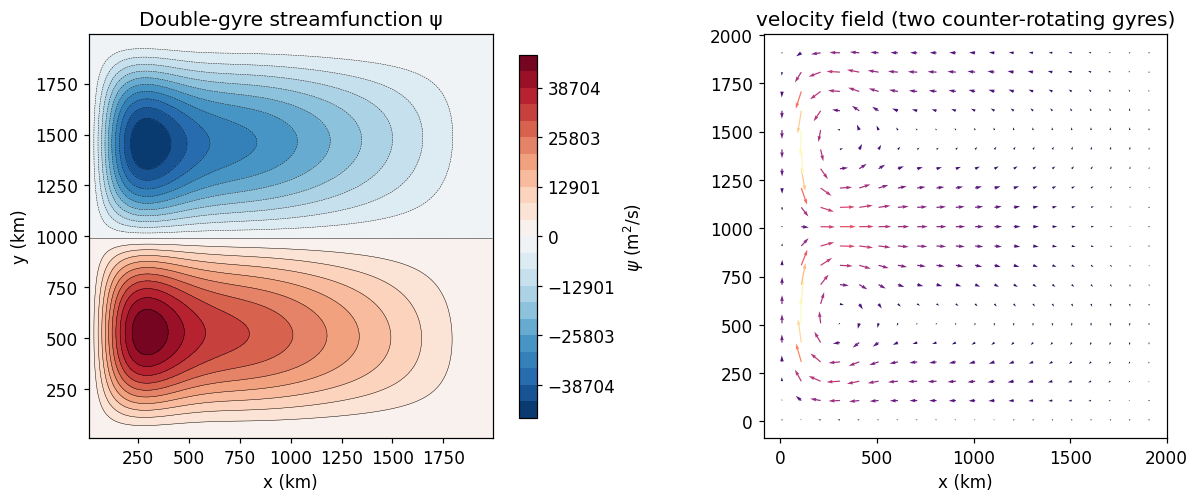

In [3]:
xkm, ykm = grid.x_eta/1e3, grid.y_eta/1e3
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.7))
lim = np.abs(psi).max()
cf = axes[0].contourf(xkm, ykm, psi, np.linspace(-lim, lim, 23), cmap="RdBu_r")
axes[0].contour(xkm, ykm, psi, np.linspace(-lim, lim, 23), colors="k", linewidths=0.3)
axes[0].set_title("Double-gyre streamfunction ψ"); axes[0].set_aspect("equal")
axes[0].set_xlabel("x (km)"); axes[0].set_ylabel("y (km)")
fig.colorbar(cf, ax=axes[0], label=r"$\psi$ (m$^2$/s)", shrink=0.9)
skip = 6
axes[1].quiver(xkm[::skip], ykm[::skip], uc[::skip, ::skip], vc[::skip, ::skip],
               np.hypot(uc, vc)[::skip, ::skip], cmap="magma", scale=4)
axes[1].set_title("velocity field (two counter-rotating gyres)")
axes[1].set_aspect("equal"); axes[1].set_xlabel("x (km)")
fig.tight_layout(); fig.savefig(FIG / "06_double_gyre.png", bbox_inches="tight"); plt.show()

### 속도장 저장

다른 실습에서 쓸 수 있도록 정상상태 속도장을 `outputs/fields/` 에 저장한다.

In [4]:
field_path = FIELDS / "double_gyre_velocity.npz"
np.savez(field_path, x=grid.x_eta, y=grid.y_eta, u=uc, v=vc, eta=res["eta"],
         psi=psi, Lx=Lx, Ly=Ly)
print("saved →", field_path.relative_to(PROJECT_ROOT))

saved → outputs/fields/double_gyre_velocity.npz


## 3. 결합 ① — 입자추적 (라그랑지안)

저장한 속도장을 이중선형 보간하고, $\dfrac{d\mathbf{x}}{dt}=\mathbf{u}(\mathbf{x})$ 를
**RK4** 로 적분해 입자를 따라간다 (`particle-tracking-lab` 과 동일한 아이디어).
정상류이므로 입자 궤적은 유선($\psi$=const)과 일치해야 한다.

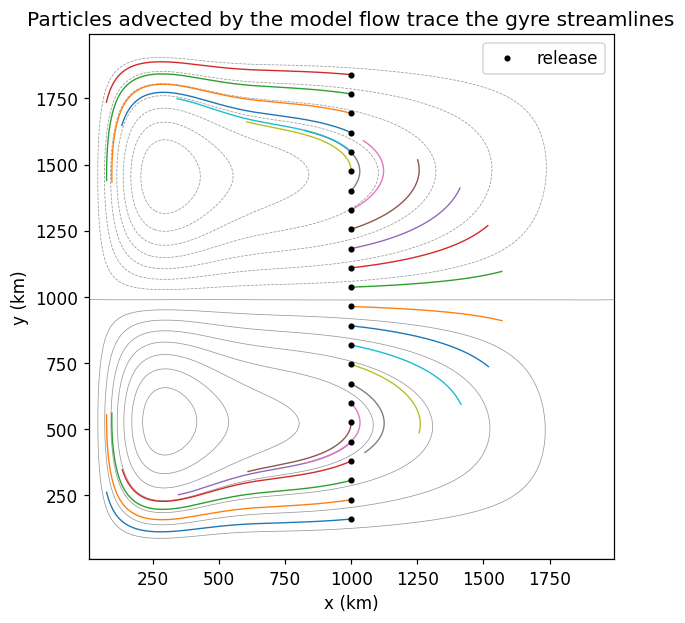

In [5]:
ui = RegularGridInterpolator((grid.y_eta, grid.x_eta), uc, bounds_error=False, fill_value=0.0)
vi = RegularGridInterpolator((grid.y_eta, grid.x_eta), vc, bounds_error=False, fill_value=0.0)

def velocity(p):                      # p: (N,2) = (x, y)
    pts = np.column_stack([p[:, 1], p[:, 0]])   # (y, x)
    return np.column_stack([ui(pts), vi(pts)])

def rk4(p, dt):
    k1 = velocity(p); k2 = velocity(p + 0.5*dt*k1)
    k3 = velocity(p + 0.5*dt*k2); k4 = velocity(p + dt*k3)
    return p + dt/6.0 * (k1 + 2*k2 + 2*k3 + k4)

# 분지를 가로지르는 입자 띠를 뿌린다
ny_seed = 24
p = np.column_stack([np.full(ny_seed, Lx*0.5),
                     np.linspace(0.08*Ly, 0.92*Ly, ny_seed)])
dt_p = 6 * 3600.0
nT = int(120 * 86400 / dt_p)          # 120 days
traj = np.zeros((nT + 1, ny_seed, 2)); traj[0] = p
for t in range(nT):
    p = rk4(p, dt_p); traj[t + 1] = p

fig, ax = plt.subplots(figsize=(6.2, 5.8))
ax.contour(xkm, ykm, psi, 15, colors="0.6", linewidths=0.5)
for j in range(ny_seed):
    ax.plot(traj[:, j, 0]/1e3, traj[:, j, 1]/1e3, lw=0.9)
ax.plot(traj[0, :, 0]/1e3, traj[0, :, 1]/1e3, "ko", ms=3, label="release")
ax.set_aspect("equal"); ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
ax.set_title("Particles advected by the model flow trace the gyre streamlines")
ax.legend(loc="upper right")
fig.tight_layout(); fig.savefig(FIG / "06_particles.png", bbox_inches="tight"); plt.show()

## 4. 결합 ② — 트레이서 수송 (오일러리안)

같은 속도장 위에서 수동 트레이서 $C$ 를 이류·확산시킨다. 여기서는
**준라그랑지안(semi-Lagrangian)** 으로 한 스텝마다 출발점을 역추적해 $C$ 를
보간하고(무조건 안정), 약한 확산을 더한다 (`advection-diffusion-lab` 과 동일한 문제).
서쪽 경계류와 gyre 가 트레이서를 **필라멘트**로 늘여 섞는 모습을 본다.

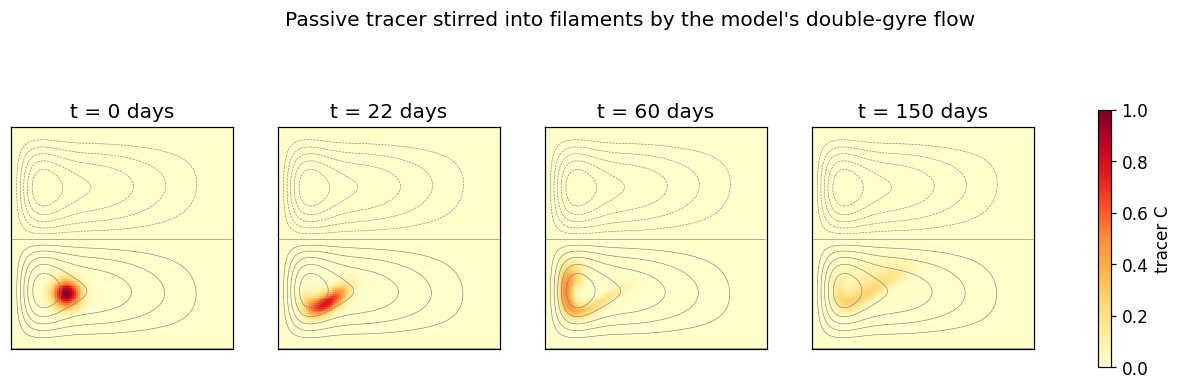

트레이서 질량: 초기 4.524e+10 → 최종 4.003e+10 (-11.5%)
(준라그랑지안은 엄밀히 질량보존이 아니다 — 보존이 중요하면 flux-form 이류를 쓴다.)


In [6]:
Xc, Yc = grid.meshgrid_eta()
x0, y0 = grid.x_eta[0], grid.y_eta[0]
dx, dy = grid.dx, grid.dy

def laplacian(C):
    Cp = np.pad(C, 1, mode="edge")
    return ((Cp[1:-1, 2:] - 2*Cp[1:-1, 1:-1] + Cp[1:-1, :-2]) / dx**2
            + (Cp[2:, 1:-1] - 2*Cp[1:-1, 1:-1] + Cp[:-2, 1:-1]) / dy**2)

def step_tracer(C, dt, K):
    # RK2 역추적 출발점
    xd = Xc - uc * dt; yd = Yc - vc * dt
    xd = Xc - 0.5*dt*(uc + _interp(uc, xd, yd))
    yd = Yc - 0.5*dt*(vc + _interp(vc, xd, yd))
    ix = (xd - x0)/dx; iy = (yd - y0)/dy
    Cn = map_coordinates(C, [iy, ix], order=1, mode="nearest")
    return Cn + K * dt * laplacian(Cn)

def _interp(field, xq, yq):
    ix = (xq - x0)/dx; iy = (yq - y0)/dy
    return map_coordinates(field, [iy, ix], order=1, mode="nearest")

# 초기 트레이서: 남쪽 gyre 서편의 둥근 패치
C = np.exp(-(((Xc - 0.25*Lx)**2 + (Yc - 0.25*Ly)**2)) / (1.2e5)**2)
dt_c = 6 * 3600.0; K = 60.0
snaps = {0: C.copy()}
nC = int(150 * 86400 / dt_c)
for t in range(1, nC + 1):
    C = step_tracer(C, dt_c, K)
    if t in (int(nC*0.15), int(nC*0.4), nC):
        snaps[t] = C.copy()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, (t, field) in zip(axes, sorted(snaps.items())):
    im = ax.pcolormesh(xkm, ykm, field, cmap="YlOrRd", vmin=0, vmax=1, shading="auto")
    ax.contour(xkm, ykm, psi, 12, colors="0.5", linewidths=0.4)
    ax.set_title(f"t = {t*dt_c/86400:.0f} days"); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, label="tracer C", shrink=0.8)
fig.suptitle("Passive tracer stirred into filaments by the model's double-gyre flow", y=1.04)
fig.savefig(FIG / "06_tracer.png", bbox_inches="tight"); plt.show()
m_init, m_end = snaps[0].sum()*dx*dy, C.sum()*dx*dy
print(f"트레이서 질량: 초기 {m_init:.3e} → 최종 {m_end:.3e} "
      f"({(m_end/m_init-1)*100:+.1f}%)")
print("(준라그랑지안은 엄밀히 질량보존이 아니다 — 보존이 중요하면 flux-form 이류를 쓴다.)")

## 5. 자료동화로의 연결 (개념)

`lorenz-da-lab` 의 앙상블 칼만필터(EnKF)는 *모델 상태*를 *관측*으로 보정한다.
여기서 만든 천수모델 상태 $(\eta,u,v)$ 가 바로 그 "모델 상태"가 될 수 있다.

- **상태벡터**: 격자 위 $(\eta,u,v)$ 를 펼친 벡터.
- **앙상블**: 바람응력·초기조건을 섭동해 여러 번 적분.
- **관측**: 일부 격자점의 $\eta$(위성 고도계) 또는 유속.
- **분석**: EnKF 로 모델과 관측을 결합.

즉 이 시리즈는 **전진모델(여기) → 입자추적/트레이서(수송) → 자료동화(추정)** 로
하나의 흐름 위에서 모두 연결된다.

## 6. 정리 — 시리즈 마무리

- 천수방정식으로 **이중 gyre 속도장**을 직접 생성하고 저장했다.
- 그 속도장에서 **입자추적**(라그랑지안)을 수행해 궤적이 유선과 일치함을 확인했다.
- 같은 속도장 위에서 **트레이서 수송**(오일러리안)을 수행해 gyre 의 교반을 보았다.
- **자료동화**로의 연결도 정리했다.

**Shallow Water Lab 완료.** 1D 중력파(Stage 1)에서 출발해 C-grid(2),
지형류 조정(3), 회전계 파동(4), 풍성순환(5)을 거쳐, 모델이 만든 흐름을
시리즈 전체와 잇는 capstone(6)까지 마쳤다. 해석적 속도장을 *가정*하던 다른
실습들이 이제 **천수모델이 스스로 만든 속도장** 위에서 돌아간다.